# Лабораторная работа
## Тема: Нейронная сеть прямого распространения для регрессии

### 1. Название и краткая информация о сдаваемом методе

Нейронная сеть прямого распространения (feed-forward neural network) — это модель, в которой сигнал проходит последовательно от входного слоя через скрытые слои к выходному слою. В скрытых слоях нейроны вычисляют взвешенные суммы признаков, применяют нелинейные функции активации и передают результат дальше. За счет нелинейности такая модель может находить зависимости, которые плохо описываются простой линейной регрессией.

В данной лабораторной работе используется `MLPRegressor` из библиотеки `scikit-learn`. Это многослойный перцептрон для задачи регрессии, то есть для предсказания непрерывной числовой величины.

Задача работы — предсказать медианную стоимость жилья в районах Калифорнии по социально-экономическим и географическим признакам. Используется признанный датасет **California Housing**: **20 640 объектов**, **8 признаков**, задача регрессии. Данные используются полностью, без искусственной балансировки, подвыборок и изменения целевой переменной.
        


### 2. Блок с используемыми библиотеками

В работе используются `pandas` и `numpy` для обработки табличных данных, `matplotlib` и `seaborn` для визуализации, а также инструменты `scikit-learn` для загрузки датасета, разбиения выборки, масштабирования признаков, обучения моделей и оценки качества регрессии.
        


In [15]:
import os
import warnings
from pathlib import Path

os.environ["LOKY_MAX_CPU_COUNT"] = "4"
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.datasets import fetch_california_housing
from sklearn.dummy import DummyRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import learning_curve, train_test_split, validation_curve
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid", font_scale=1.0)
RANDOM_STATE = 42
TEST_SIZE = 0.2


def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def regression_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": rmse(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
    }
        


### 3. Блок с описанием и демонстрацией используемого датасета

Для лабораторной работы выбран **California Housing** — классический датасет для задачи регрессии. Он основан на данных переписи населения Калифорнии и используется для прогнозирования медианной стоимости жилья в районах штата.

Датасет содержит **20 640 объектов** и **8 признаков**:

- `MedInc` — медианный доход в районе;
- `HouseAge` — медианный возраст домов;
- `AveRooms` — среднее количество комнат;
- `AveBedrms` — среднее количество спален;
- `Population` — население района;
- `AveOccup` — среднее число жителей на домохозяйство;
- `Latitude` — широта;
- `Longitude` — долгота.

Целевая переменная `MedHouseVal` — медианная стоимость жилья в сотнях тысяч долларов. Это непрерывная числовая величина, поэтому задача является регрессионной.
        


In [16]:
data_home_candidates = [
    Path(r"C:\Users\avdee\PycharmProjects\mmo-2026\block-4\neural-network\sklearn_data"),
    Path("block-4") / "neural-network" / "sklearn_data",
    Path("sklearn_data"),
]

for candidate in data_home_candidates:
    if candidate.exists():
        DATA_HOME = candidate
        break
else:
    DATA_HOME = Path("sklearn_data")

dataset = fetch_california_housing(data_home=str(DATA_HOME), as_frame=True)
df = dataset.frame.copy()

print(f"Используемый data_home: {DATA_HOME}")
print(f"Размер датасета: {df.shape[0]} строк и {df.shape[1]} столбцов")
print(f"Количество признаков: {len(dataset.feature_names)}")
print("Целевая переменная: MedHouseVal")
display(df.head(10))
        


Используемый data_home: C:\Users\avdee\PycharmProjects\mmo-2026\block-4\neural-network\sklearn_data
Размер датасета: 20640 строк и 9 столбцов
Количество признаков: 8
Целевая переменная: MedHouseVal


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
5,4.0368,52.0,4.761658,1.103627,413.0,2.139896,37.85,-122.25,2.697
6,3.6591,52.0,4.931907,0.951362,1094.0,2.128405,37.84,-122.25,2.992
7,3.1200,52.0,4.797527,1.061824,1157.0,1.788253,37.84,-122.25,2.414
8,2.0804,42.0,4.294118,1.117647,1206.0,2.026891,37.84,-122.26,2.267
9,3.6912,52.0,4.970588,0.990196,1551.0,2.172269,37.84,-122.25,2.611


Информация о датасете:
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB

Статистическое описание:


,count,mean,std,min,25%,50%,75%,max
MedInc,20640.0,3.871,1.900,0.500,2.563,3.535,4.743,15.000
HouseAge,20640.0,28.639,12.586,1.000,18.000,29.000,37.000,52.000
AveRooms,20640.0,5.429,2.474,0.846,4.441,5.229,6.052,141.909
AveBedrms,20640.0,1.097,0.474,0.333,1.006,1.049,1.100,34.067
Population,20640.0,1425.477,1132.462,3.000,787.000,1166.000,1725.000,35682.000
AveOccup,20640.0,3.071,10.386,0.692,2.430,2.818,3.282,1243.333
Latitude,20640.0,35.632,2.136,32.540,33.930,34.260,37.710,41.950
Longitude,20640.0,-119.570,2.004,-124.350,-121.800,-118.490,-118.010,-114.310
MedHouseVal,20640.0,2.069,1.154,0.150,1.196,1.797,2.647,5.000



Количество пропусков по столбцам:


,missing_values
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
MedHouseVal,0


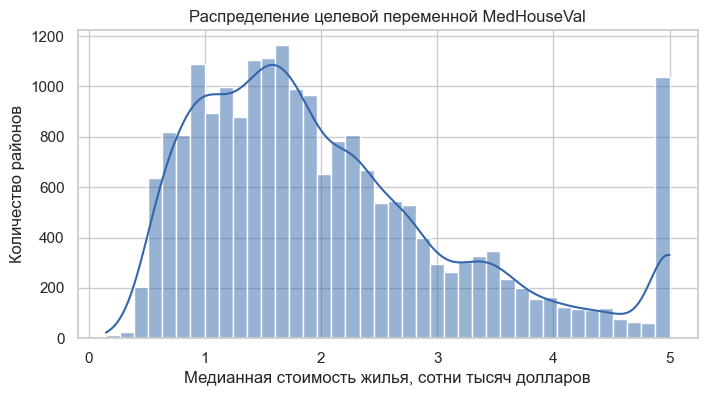

In [17]:
print("Информация о датасете:")
df.info()

print("\nСтатистическое описание:")
display(df.describe().T.round(3))

print("\nКоличество пропусков по столбцам:")
display(df.isnull().sum().to_frame("missing_values"))

plt.figure(figsize=(8, 4))
sns.histplot(df["MedHouseVal"], bins=40, kde=True, color="#3366aa")
plt.title("Распределение целевой переменной MedHouseVal")
plt.xlabel("Медианная стоимость жилья, сотни тысяч долларов")
plt.ylabel("Количество районов")
plt.show()
        


### 4. Предварительная обработка датасета

Данные используются без искусственных изменений: без балансировки, без подвыборки и без замены целевой переменной. Выполняются только стандартные шаги машинного обучения:

- отделение признаков от целевой переменной;
- разбиение на обучающую и тестовую выборки;
- масштабирование признаков внутри `Pipeline`.

Масштабирование важно для нейронной сети, потому что `MLPRegressor` чувствителен к масштабу входных признаков.
        


In [18]:
X = df.drop(columns=["MedHouseVal"])
y = df["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")
print(f"Среднее значение цели в обучающей выборке: {y_train.mean():.3f}")
print(f"Среднее значение цели в тестовой выборке: {y_test.mean():.3f}")
        


Размер обучающей выборки: (16512, 8)
Размер тестовой выборки: (4128, 8)
Среднее значение цели в обучающей выборке: 2.072
Среднее значение цели в тестовой выборке: 2.055


### 5. Блок с тепловой картой

Тепловая карта показывает линейные связи между признаками и целевой переменной. Она помогает понять, какие признаки сильнее связаны со стоимостью жилья.
        


Корреляция признаков с MedHouseVal:


,corr_with_target
MedInc,0.688
AveRooms,0.152
Latitude,-0.144
HouseAge,0.106
AveBedrms,-0.047
Longitude,-0.046
Population,-0.025
AveOccup,-0.024


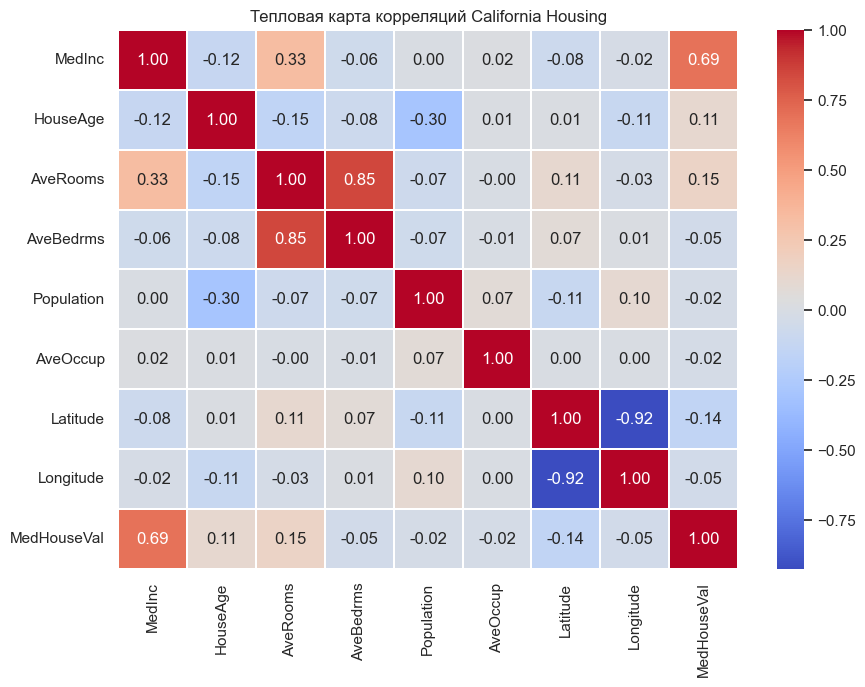

In [19]:
corr = df.corr(numeric_only=True)
target_corr = (
    corr["MedHouseVal"]
    .drop("MedHouseVal")
    .sort_values(key=lambda values: values.abs(), ascending=False)
)

print("Корреляция признаков с MedHouseVal:")
display(target_corr.round(3).to_frame("corr_with_target"))

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.3)
plt.title("Тепловая карта корреляций California Housing")
plt.show()
        


### 7. Блок с обучением модели

Для контроля качества обучаются три модели:

- `DummyRegressor` — наивная baseline-модель, предсказывающая среднее значение;
- `Ridge` — линейная регрессия с L2-регуляризацией;
- `MLPRegressor` — нейронная сеть прямого распространения.

Если нейронная сеть работает корректно, она должна заметно превосходить наивный baseline и быть конкурентной простой линейной модели.
        


In [21]:
def make_mlp(alpha=0.0001, hidden_layer_sizes=(128, 64), learning_rate_init=0.001, max_iter=500):
    return Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            (
                "regressor",
                MLPRegressor(
                    hidden_layer_sizes=hidden_layer_sizes,
                    activation="relu",
                    solver="adam",
                    alpha=alpha,
                    learning_rate_init=learning_rate_init,
                    max_iter=max_iter,
                    early_stopping=True,
                    validation_fraction=0.15,
                    n_iter_no_change=20,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    )


models = {
    "DummyRegressor": DummyRegressor(strategy="mean"),
    "Ridge": Pipeline([("scaler", StandardScaler()), ("regressor", Ridge(alpha=1.0))]),
    "MLPRegressor": make_mlp(alpha=0.0001, hidden_layer_sizes=(128, 64)),
}

predictions = {}
metrics_rows = []

for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    predictions[model_name] = y_pred
    metrics_rows.append({"model": model_name, **regression_metrics(y_test, y_pred)})

metrics_df = pd.DataFrame(metrics_rows).set_index("model").sort_values("RMSE")
display(metrics_df.round(4))

best_model = models["MLPRegressor"]
mlp_core = best_model.named_steps["regressor"]
print(f"Количество эпох обучения MLPRegressor: {mlp_core.n_iter_}")
print(f"Финальное значение loss: {mlp_core.loss_:.4f}")
        


,MAE,RMSE,R2
model,,,
MLPRegressor,0.3484,0.5198,0.7938
Ridge,0.5332,0.7456,0.5758
DummyRegressor,0.9061,1.1449,-0.0002


Количество эпох обучения MLPRegressor: 126
Финальное значение loss: 0.1127


### 8. Визуализация процесса обучения и качества прогноза

Для регрессии важно проверить не только метрики, но и графики: функцию потерь, совпадение фактических и предсказанных значений, а также распределение остатков.
        


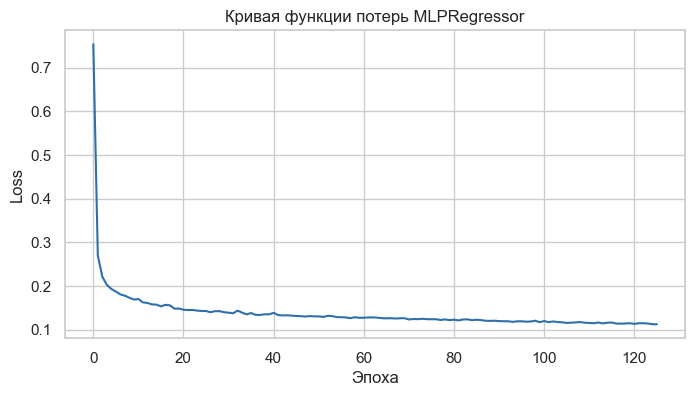

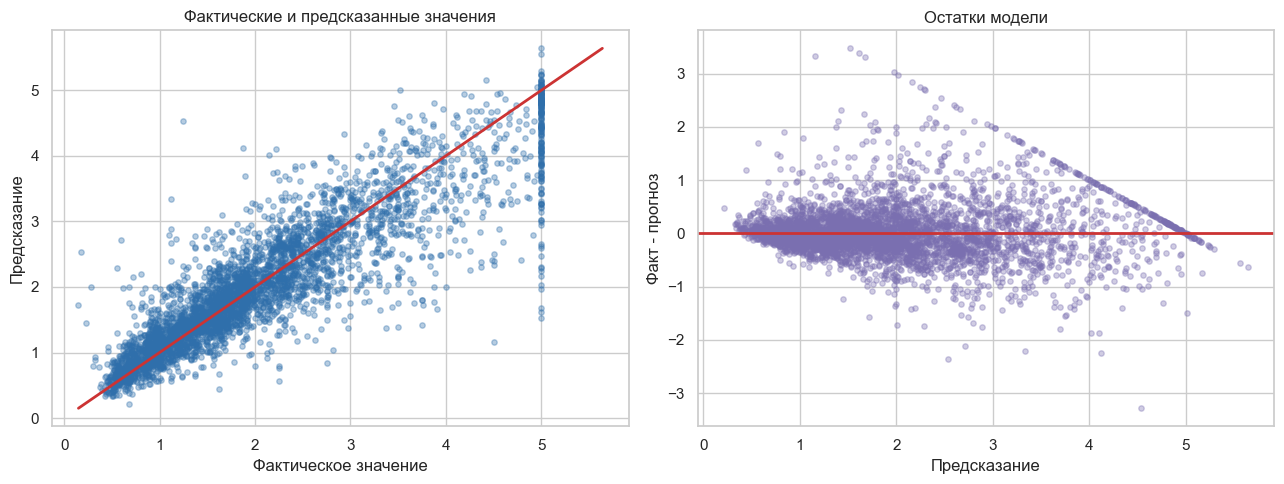

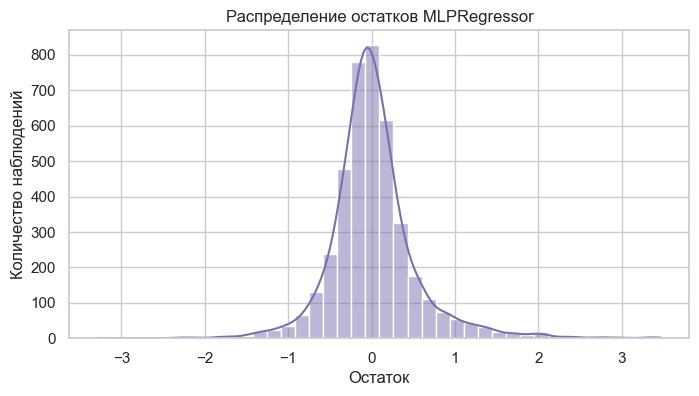

In [22]:
plt.figure(figsize=(8, 4))
plt.plot(mlp_core.loss_curve_, color="#2f6fab")
plt.title("Кривая функции потерь MLPRegressor")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.show()

y_pred_mlp = predictions["MLPRegressor"]
residuals = y_test - y_pred_mlp

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(y_test, y_pred_mlp, alpha=0.35, color="#2f6fab", s=15)
min_value = min(y_test.min(), y_pred_mlp.min())
max_value = max(y_test.max(), y_pred_mlp.max())
axes[0].plot([min_value, max_value], [min_value, max_value], color="#cc3333", linewidth=2)
axes[0].set_title("Фактические и предсказанные значения")
axes[0].set_xlabel("Фактическое значение")
axes[0].set_ylabel("Предсказание")

axes[1].scatter(y_pred_mlp, residuals, alpha=0.35, color="#7a6fb0", s=15)
axes[1].axhline(0, color="#cc3333", linewidth=2)
axes[1].set_title("Остатки модели")
axes[1].set_xlabel("Предсказание")
axes[1].set_ylabel("Факт - прогноз")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
sns.histplot(residuals, bins=40, kde=True, color="#7a6fb0")
plt.title("Распределение остатков MLPRegressor")
plt.xlabel("Остаток")
plt.ylabel("Количество наблюдений")
plt.show()
        


### 9. Подбор регуляризации

Параметр `alpha` отвечает за L2-регуляризацию весов нейронной сети. Ниже строится validation curve для нескольких значений `alpha`.
        


,alpha,train_RMSE,valid_RMSE,gap
0,0.0001,0.4798,0.5289,0.0491
1,0.0010,0.4720,0.5276,0.0556
2,0.0100,0.4849,0.5293,0.0445
3,0.1000,0.4942,0.5318,0.0375


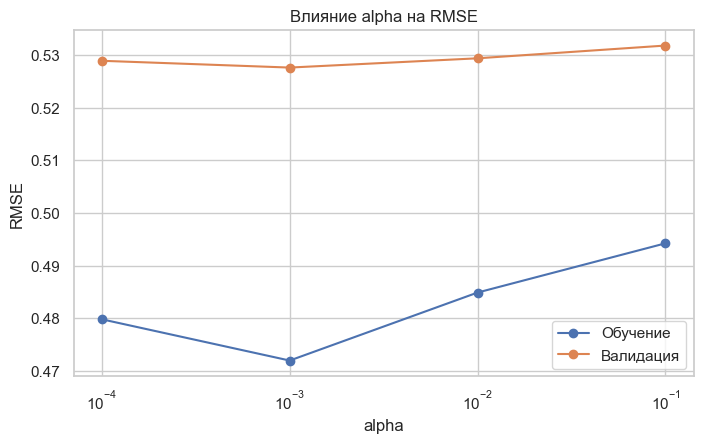

In [23]:
alpha_values = np.array([0.0001, 0.001, 0.01, 0.1])

train_scores, valid_scores = validation_curve(
    make_mlp(hidden_layer_sizes=(128, 64), max_iter=350),
    X_train,
    y_train,
    param_name="regressor__alpha",
    param_range=alpha_values,
    cv=3,
    scoring="neg_root_mean_squared_error",
    n_jobs=1,
)

validation_df = pd.DataFrame(
    {
        "alpha": alpha_values,
        "train_RMSE": -train_scores.mean(axis=1),
        "valid_RMSE": -valid_scores.mean(axis=1),
    }
)
validation_df["gap"] = validation_df["valid_RMSE"] - validation_df["train_RMSE"]
display(validation_df.round(4))

plt.figure(figsize=(8, 4.5))
plt.semilogx(validation_df["alpha"], validation_df["train_RMSE"], marker="o", label="Обучение")
plt.semilogx(validation_df["alpha"], validation_df["valid_RMSE"], marker="o", label="Валидация")
plt.title("Влияние alpha на RMSE")
plt.xlabel("alpha")
plt.ylabel("RMSE")
plt.legend()
plt.show()
        


### 10. Сравнение архитектур

Проверяются несколько архитектур нейронной сети. Это показывает, как количество нейронов и скрытых слоев влияет на качество регрессии.
        


,hidden_layer_sizes,MAE,RMSE,R2,n_iter
2,"(128, 64, 32)",0.3484,0.5175,0.7956,103
1,"(128, 64)",0.3484,0.5198,0.7938,126
0,"(64,)",0.3684,0.5460,0.7725,224


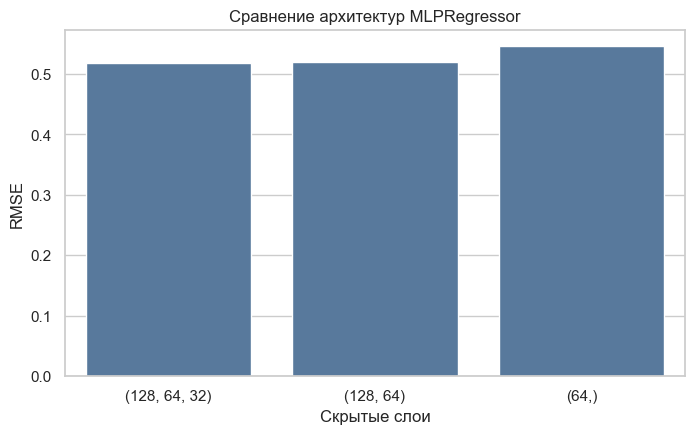

In [24]:
architectures = [(64,), (128, 64), (128, 64, 32)]

architecture_rows = []
for architecture in architectures:
    candidate = make_mlp(alpha=0.0001, hidden_layer_sizes=architecture, max_iter=400)
    candidate.fit(X_train, y_train)
    candidate_pred = candidate.predict(X_test)
    candidate_metrics = regression_metrics(y_test, candidate_pred)
    architecture_rows.append(
        {
            "hidden_layer_sizes": str(architecture),
            "MAE": candidate_metrics["MAE"],
            "RMSE": candidate_metrics["RMSE"],
            "R2": candidate_metrics["R2"],
            "n_iter": candidate.named_steps["regressor"].n_iter_,
        }
    )

architecture_df = pd.DataFrame(architecture_rows).sort_values("RMSE")
display(architecture_df.round(4))

plt.figure(figsize=(8, 4.5))
sns.barplot(data=architecture_df, x="hidden_layer_sizes", y="RMSE", color="#4c78a8")
plt.title("Сравнение архитектур MLPRegressor")
plt.xlabel("Скрытые слои")
plt.ylabel("RMSE")
plt.show()
        


### 11. Кривая обучения

Кривая обучения показывает, как меняется ошибка при увеличении объема обучающих данных.
        


,train_size,train_RMSE,valid_RMSE
0,2752,0.4982,0.8210
1,5504,0.4866,0.5474
2,8256,0.4824,0.5293
3,11008,0.4798,0.5289


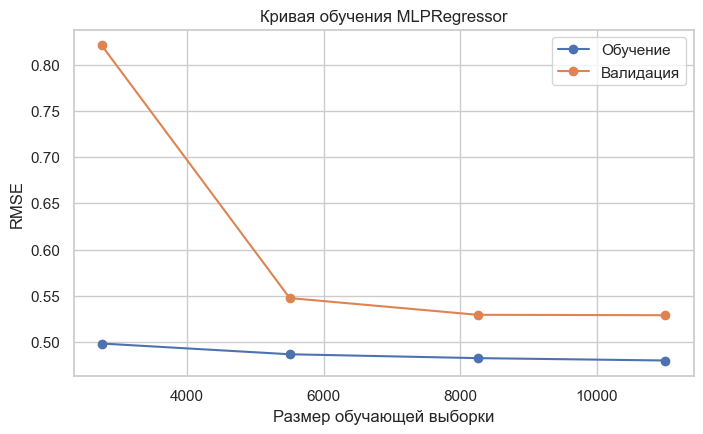

In [25]:
train_sizes, learning_train_scores, learning_valid_scores = learning_curve(
    make_mlp(alpha=0.0001, hidden_layer_sizes=(128, 64), max_iter=350),
    X_train,
    y_train,
    train_sizes=np.array([0.25, 0.5, 0.75, 1.0]),
    cv=3,
    scoring="neg_root_mean_squared_error",
    n_jobs=1,
)

learning_df = pd.DataFrame(
    {
        "train_size": train_sizes,
        "train_RMSE": -learning_train_scores.mean(axis=1),
        "valid_RMSE": -learning_valid_scores.mean(axis=1),
    }
)
display(learning_df.round(4))

plt.figure(figsize=(8, 4.5))
plt.plot(learning_df["train_size"], learning_df["train_RMSE"], marker="o", label="Обучение")
plt.plot(learning_df["train_size"], learning_df["valid_RMSE"], marker="o", label="Валидация")
plt.title("Кривая обучения MLPRegressor")
plt.xlabel("Размер обучающей выборки")
plt.ylabel("RMSE")
plt.legend()
plt.show()
        


### 12. Важность признаков

Для оценки важности признаков используется permutation importance. Чем сильнее растет ошибка после перемешивания признака, тем важнее этот признак для модели.
        


,feature,importance_mean,importance_std
0,Latitude,1.0984,0.0140
1,Longitude,0.9876,0.0154
2,MedInc,0.3795,0.0081
3,AveRooms,0.3786,0.0129
4,AveBedrms,0.2688,0.0097
5,AveOccup,0.2321,0.0073
6,HouseAge,0.0806,0.0038
7,Population,0.0176,0.0020


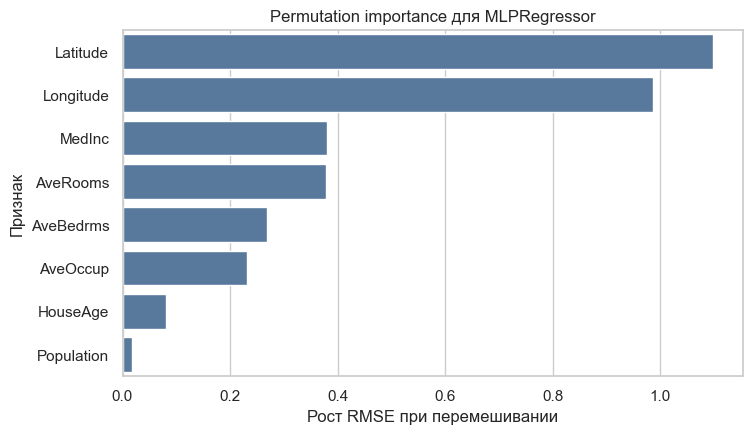

In [26]:
importance = permutation_importance(
    best_model,
    X_test,
    y_test,
    scoring="neg_root_mean_squared_error",
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=1,
)

importance_df = (
    pd.DataFrame(
        {
            "feature": X.columns,
            "importance_mean": importance.importances_mean,
            "importance_std": importance.importances_std,
        }
    )
    .sort_values("importance_mean", ascending=False)
    .reset_index(drop=True)
)
display(importance_df.round(4))

plt.figure(figsize=(8, 4.5))
sns.barplot(data=importance_df, x="importance_mean", y="feature", color="#4c78a8")
plt.title("Permutation importance для MLPRegressor")
plt.xlabel("Рост RMSE при перемешивании")
plt.ylabel("Признак")
plt.show()
        


### 13. Примеры прогнозов модели

Ниже показаны отдельные объекты из тестовой выборки: фактическое значение, прогноз и абсолютная ошибка.
        


In [27]:
examples = X_test.copy()
examples["actual_MedHouseVal"] = y_test
examples["predicted_MedHouseVal"] = y_pred_mlp
examples["absolute_error"] = np.abs(examples["actual_MedHouseVal"] - examples["predicted_MedHouseVal"])

print("10 объектов с наименьшей ошибкой:")
display(
    examples[["actual_MedHouseVal", "predicted_MedHouseVal", "absolute_error"]]
    .sort_values("absolute_error")
    .head(10)
    .round(3)
)

print("10 объектов с наибольшей ошибкой:")
display(
    examples[["actual_MedHouseVal", "predicted_MedHouseVal", "absolute_error"]]
    .sort_values("absolute_error", ascending=False)
    .head(10)
    .round(3)
)
        


10 объектов с наименьшей ошибкой:


,actual_MedHouseVal,predicted_MedHouseVal,absolute_error
205,1.225,1.225,0.000
2635,0.851,0.851,0.000
15530,1.611,1.611,0.000
8530,2.250,2.249,0.001
15609,3.003,3.002,0.001
6352,1.845,1.846,0.001
17387,1.137,1.136,0.001
6301,1.333,1.334,0.001
18636,3.553,3.554,0.001
14736,2.542,2.541,0.001


10 объектов с наибольшей ошибкой:


,actual_MedHouseVal,predicted_MedHouseVal,absolute_error
6688,5.00,1.526,3.474
459,5.00,1.617,3.383
19542,4.50,1.160,3.340
12389,5.00,1.681,3.319
20349,1.25,4.536,3.286
10574,5.00,1.977,3.023
15624,5.00,2.023,2.977
15652,5.00,2.165,2.835
12069,5.00,2.245,2.755
4630,5.00,2.290,2.710


### 14. Итоговый вывод

В лабораторной работе была построена нейронная сеть прямого распространения для задачи регрессии. Использован признанный датасет **California Housing**, содержащий **20 640 объектов** и **8 признаков**. Данные использованы полностью, без искусственной балансировки, подвыборки и изменения целевой переменной.

В ходе работы выполнены:

- загрузка и описание датасета;
- анализ пропусков и статистик;
- построение распределения целевой переменной;
- тепловая карта корреляций;
- стандартная предобработка через `StandardScaler`;
- обучение baseline-моделей `DummyRegressor` и `Ridge`;
- обучение нейронной сети `MLPRegressor`;
- оценка качества по `MAE`, `RMSE` и `R2`;
- анализ функции потерь, остатков и фактических/предсказанных значений;
- подбор регуляризации;
- сравнение архитектур;
- построение кривой обучения;
- оценка важности признаков.

Итог: `MLPRegressor` применим для регрессионных задач на табличных данных и позволяет учитывать нелинейные зависимости между признаками. Для корректной оценки качества модель необходимо сравнивать с baseline-подходами и анализировать не только итоговые метрики, но и графики ошибок.
        
